## Deep Learning

## Offer Engine: соединяем обе модели

Это финальная часть, после табличной и текстовой моделей. Тут я собираю всё в одну систему:
табличная модель даёт мне risk по заказу, текстовая - тональность отзыва, а offer engine
(он лежит в src/offer_engine.py) по этим двум сигналам и профилю клиента решает какой оффер дать.

В конце смотрю клиентов с офферами, чтобы было видно как это работает на реальных людях, а не просто табличка с числами.

In [10]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

from tqdm import tqdm

import torch
import torch.nn as nn

from sklearn.preprocessing import StandardScaler
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# offer engine у меня в src, добавляю путь чтобы импортнуть
sys.path.append('..')
sys.path.append('src')
try:
    from src.offer_engine import make_offer
except ModuleNotFoundError:
    from offer_engine import make_offer

if torch.backends.mps.is_available():
    device = torch.device('mps')   # шобы на маке шухало все
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
device

device(type='mps')

In [11]:
orders = pd.read_csv('../data/processed/order_level_dataset.csv')
customers = pd.read_csv('../data/processed/customer_level_dataset.csv')
reviews = pd.read_csv('../data/processed/reviews_text_dataset.csv')

print(orders.shape, customers.shape, reviews.shape)

(98673, 30) (96096, 22) (40977, 12)


## Тональность по отзывам

Гружу обученный BERTimbau (лучшая текстовая модель) и прогоняю им все отзывы.
Один клиент мог оставить несколько отзывов, поэтому беру самый плохой - для удержания
важнее всего худший опыт клиента.

In [12]:
tokenizer = AutoTokenizer.from_pretrained('../models/text_bertimbau')
text_model = AutoModelForSequenceClassification.from_pretrained('../models/text_bertimbau').to(device)
text_model.eval()

texts = reviews['review_comment_message'].astype(str).tolist()

preds = []
with torch.no_grad():
    for i in tqdm(range(0, len(texts), 64)):
        batch = texts[i:i + 64]
        enc = tokenizer(batch, truncation = True, max_length = 128, padding = True, return_tensors = 'pt').to(device)
        logits = text_model(**enc).logits
        preds.extend(logits.argmax(1).cpu().numpy())

reviews['sentiment'] = [text_model.config.id2label[int(p)] for p in preds]
reviews['sentiment'].value_counts()

100%|██████████| 641/641 [11:54<00:00,  1.11s/it]


sentiment
positive    24005
negative    10338
neutral      6634
Name: count, dtype: int64

In [13]:
# привязываю отзыв к клиенту через order_id, и беру худший отзыв на клиента
rev = reviews.merge(orders[['order_id', 'customer_unique_id']], on = 'order_id', how = 'left')
rev['sev'] = rev['sentiment'].map({'negative': 0, 'neutral': 1, 'positive': 2})
sentiment = rev.sort_values('sev').groupby('customer_unique_id')['sentiment'].first()

## Риск по заказам

Тут повторяю ту же предобработку что в табличном ноуте (иначе сохранённые веса не сядут на модель),
гружу лучшую модель MLP3-reg и считаю вероятность недовольства по каждому заказу.

In [14]:
num_cols = [
    'order_total', 'items_price', 'freight_value', 'freight_share', 'payment_value',
    'payment_installments', 'payment_type_count', 'order_item_count', 'unique_products',
    'unique_sellers', 'delivery_days', 'estimated_delivery_days', 'delay_days',
    'is_late', 'not_delivered', 'multiple_sellers', 'high_installments', 'expensive_order'
]
cat_cols = ['customer_state', 'main_category', 'main_payment_type', 'order_status']

df = orders.copy()
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

df['main_category'] = df['main_category'].fillna('unknown')
df['main_payment_type'] = df['main_payment_type'].fillna('unknown')
top_cat = df['main_category'].value_counts().head(30).index
df['main_category'] = np.where(df['main_category'].isin(top_cat), df['main_category'], 'other')

cardinalities = []
for c in cat_cols:
    df[c] = df[c].astype('category')
    df[c + '_code'] = df[c].cat.codes
    cardinalities.append(df[c + '_code'].max() + 1)
cat_code_cols = [c + '_code' for c in cat_cols]

scaler = StandardScaler()
X_num = scaler.fit_transform(df[num_cols].values).astype('float32')
X_cat = df[cat_code_cols].values.astype('int64')

In [15]:
# та же сеть что в табличном ноуте
class TabularMLP(nn.Module):
    def __init__(self, n_num, cardinalities, hidden = (256, 128, 64), batchnorm = False, dropout = 0.0):
        super(TabularMLP, self).__init__()

        self.embs = nn.ModuleList([nn.Embedding(card, min(50, (card + 1) // 2)) for card in cardinalities])
        emb_dim = sum(min(50, (card + 1) // 2) for card in cardinalities)

        layers = []
        inp = n_num + emb_dim
        for h in hidden:
            layers.append(nn.Linear(inp, h))
            if batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            inp = h
        layers.append(nn.Linear(inp, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x_num, x_cat):
        e = [emb(x_cat[:, i]) for i, emb in enumerate(self.embs)]
        e = torch.cat(e, dim = 1)
        x = torch.cat([x_num, e], dim = 1)
        return self.net(x).squeeze(1)


# лучшая по recall была MLP3 - с batchnorm и dropout
model = TabularMLP(len(num_cols), cardinalities, hidden = (256, 128, 64), batchnorm = True, dropout = 0.3)
model.load_state_dict(torch.load('../models/MLP3-reg.pt', map_location = device))
model.to(device)
model.eval()

with torch.no_grad():
    x_num = torch.tensor(X_num, dtype = torch.float32).to(device)
    x_cat = torch.tensor(X_cat, dtype = torch.long).to(device)
    df['risk'] = torch.sigmoid(model(x_num, x_cat)).cpu().numpy()

# на клиента беру максимальный риск по его заказам, худший заказ важнее
risk = df.groupby('customer_unique_id')['risk'].max()

## Собираю клиентов и строю офферы

Соединяю профиль клиента (любимая категория, средний чек) с риском и тональностью,
и по каждому клиенту строю оффер через make_offer.

In [16]:
data = customers[['customer_unique_id', 'favorite_category', 'avg_order_value']]
data = data.merge(risk, on = 'customer_unique_id')
data = data.merge(sentiment, on = 'customer_unique_id', how = 'left')

offers = data.apply(lambda r: make_offer(r['risk'], r['sentiment'], r['favorite_category'], r['avg_order_value']), axis = 1)
offers = pd.DataFrame(list(offers))
result = pd.concat([data.reset_index(drop = True), offers], axis = 1)

result.to_csv('../reports/customers_with_offers.csv', index = False)
result['offer_type'].value_counts()

offer_type
loyalty              42508
targeted_reco        22011
loyalty_upsell       16293
retention_soft        8749
retention_apology     5819
Name: count, dtype: int64

## Клиенты и их офферы

Смотрю по несколько клиентов из каждой группы риска, какой оффер им выдался, и заодно
строю общую картину - сколько клиентов попало в каждый тип оффера.

In [17]:
# по несколько клиентов из каждой группы риска и какой им оффер
sample = result.groupby('risk_level').head(4)
sample[['risk', 'risk_level', 'sentiment', 'favorite_category', 'avg_order_value', 'offer_type', 'discount_pct']]

,risk,risk_level,sentiment,favorite_category,avg_order_value,offer_type,discount_pct
0,0.358265,medium,positive,bed_bath_table,141.90,targeted_reco,8
1,0.157782,low,NaN,health_beauty,27.19,loyalty,0
2,0.210448,low,NaN,stationery,86.22,loyalty,0
3,0.467713,medium,positive,telephony,43.62,targeted_reco,8
4,0.446747,medium,NaN,telephony,196.89,targeted_reco,8
5,0.190922,low,NaN,garden_tools,166.98,loyalty,0
6,0.416602,medium,NaN,telephony,35.38,targeted_reco,8
7,0.611688,high,negative,sports_leisure,419.18,retention_apology,30
8,0.257637,low,NaN,fashion_bags_accessories,150.12,loyalty,0
9,0.984171,high,negative,sports_leisure,129.76,retention_apology,25


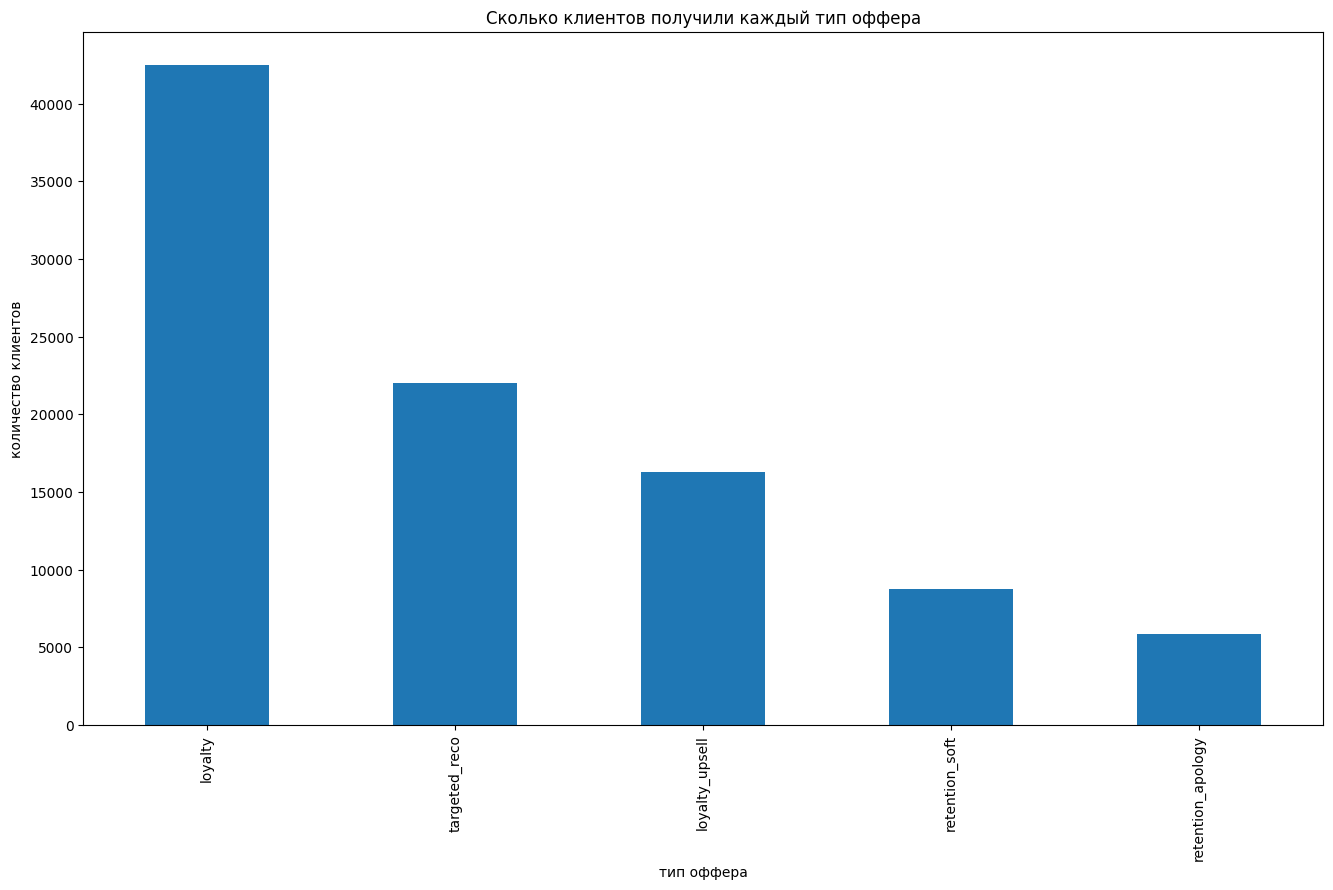

In [18]:
# общая картина - сколько клиентов в каждом типе оффера
plt.figure(figsize = (16, 9))
result['offer_type'].value_counts().plot(kind = 'bar')
plt.title('Сколько клиентов получили каждый тип оффера')
plt.xlabel('тип оффера')
plt.ylabel('количество клиентов')
plt.savefig('../reports/offers_overview.png')

In [19]:
# пример персональных сообщений
for _, r in result.sample(4, random_state = 42).iterrows():
    print(r['offer_type'], '| скидка', r['discount_pct'], '%')
    print(r['message'])
    print()

loyalty | скидка 0 %
Рекомендуем новинки в «health_beauty».

loyalty | скидка 0 %
Рекомендуем новинки в «garden_tools».

loyalty | скидка 0 %
Рекомендуем новинки в «bed_bath_table».

targeted_reco | скидка 8 %
Думаем вам понравится новое в «watches_gifts», плюс 8% на заказ.

